# **Importing zipfile from drive**

In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# 🔴 Modify this: path to your Speech_Dataset.zip
ZIP_PATH = "/content/drive/MyDrive/Speech_Dataset.zip"

# Extraction folder
EXTRACT_PATH = "/content/dataset"

# Extract zip
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

# Root dataset folder containing class folders
DEMENTIA_PATH = os.path.join(EXTRACT_PATH, "Speech_Dataset/Dementia/dementia")
NODEMENTIA_PATH = os.path.join(EXTRACT_PATH, "Speech_Dataset/No_Dementia/nodementia")

# Quick check
print("Dementia folder exists:", os.path.exists(DEMENTIA_PATH))
print("Non-Dementia folder exists:", os.path.exists(NODEMENTIA_PATH))


# **Importing Libraries**

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
import matplotlib.pyplot as plt


# **Loading Dataset & Preprocessing Audio**

In [ ]:
def load_audio_class(folder_path, label):
    features, labels = [], []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith((".wav", ".mp3")):
                file_path = os.path.join(root, file)
                try:
                    y, sr = librosa.load(file_path, sr=16000)
                    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
                    mfcc_scaled = np.mean(mfcc.T, axis=0)
                    # Normalize MFCC
                    mfcc_scaled = (mfcc_scaled - np.mean(mfcc_scaled)) / np.std(mfcc_scaled)
                    features.append(mfcc_scaled)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
    return features, labels

# Load Dementia and Non-Dementia samples
dementia_features, dementia_labels = load_audio_class(DEMENTIA_PATH, 1)
nodementia_features, nodementia_labels = load_audio_class(NODEMENTIA_PATH, 0)

# Combine features and labels
X = np.array(dementia_features + nodementia_features)
y = np.array(dementia_labels + nodementia_labels)

print("Total samples loaded:", len(X))
print("Class distribution:", np.unique(y, return_counts=True))


Total samples loaded: 455
Class distribution: (array([0, 1]), array([324, 131]))


# **Train/Test Split and One-Hot Encoding**

In [ ]:
# One-hot encoding
y_cat = to_categorical(y, num_classes=2)

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

# Reshape for 1D CNN (samples, features, channels)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 364
Validation samples: 91


# **Computing Class Weights**

In [ ]:
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(0.7027027027027027), 1: np.float64(1.7333333333333334)}


# **Build 1D CNN Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,418 (611.01 KB)

 Trainable params: 156,418 (611.01 KB)

 Non-trainable params: 0 (0.00 B)

# **Train Model with EarlyStopping and Class Weights**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,           # Adjust based on dataset size
    batch_size=32,        # Adjust based on GPU memory
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 0.6453 - loss: 0.6847 - val_accuracy: 0.2967 - val_loss: 0.7065
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3446 - loss: 0.7215 - val_accuracy: 0.5275 - val_loss: 0.6924
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6722 - loss: 0.6740 - val_accuracy: 0.7143 - val_loss: 0.6501
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6406 - loss: 0.6741 - val_accuracy: 0.3077 - val_loss: 0.7029
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4119 - loss: 0.6831 - val_accuracy: 0.5604 - val_loss: 0.6853
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6204 - loss: 0.6782 - val_accuracy: 0.7143 - val_loss: 0.6609
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5872 - loss: 0.6915 - val_accuracy: 0.7033 - val_loss: 0.6599
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7067 - loss: 0.6380 - val_accuracy: 0.4945 -

# **Visualization of Training History**

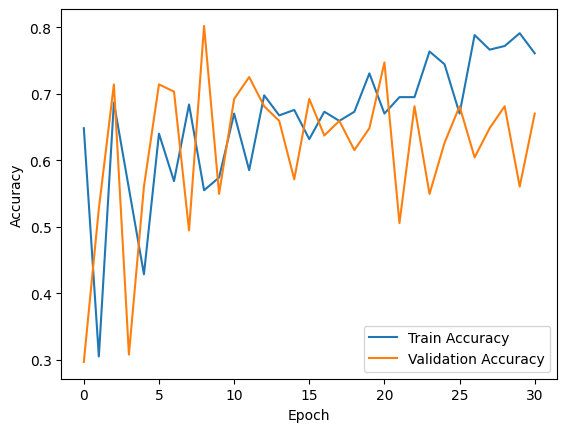

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
